# IMU Data Visualization & Rep Segmentation
Visualize accelerometer and gyroscope signals from `OurData`, filtered by **ID** (one unique ID per set).  
Includes per-rep segmentation via peak detection on the smoothed accelerometer magnitude.

**Units:** Accelerometer data is converted from g → m/s². Gyroscope data is converted from rad/s → °/s.

---
## 0. Setup

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
from scipy.ndimage import uniform_filter1d
from scipy.interpolate import interp1d
from matplotlib.lines import Line2D

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
drive_base = "/content/drive/MyDrive/Spring 2026/Wearable Health Technologies/1A Activity Recognition/Data & Code & Resources/MyoGym Model/data"
print(os.listdir(drive_base))

['Archives', 'golden_dataset_v10_40Hz.csv', 'golden_dataset_v10_10Hz.csv', 'OurData_v5_10Hz.csv', 'OurData_v5_40Hz.csv', 'OurData_v5_10Hz.gsheet', 'OurData_v5_scaled_20Hz.csv', 'OurData_v5_scaled_20Hz.gsheet', 'golden_dataset_v10_20Hz.csv', 'golden_dataset_v10_20Hz.gsheet']


---
## 1. Configuration
Change `PLOT_ID` to inspect a different exercise set. Each unique ID corresponds to one set (10 reps).

In [ ]:
# ============================================================
# CONFIGURATION — edit these values
# ============================================================
DATA_PATH = "/content/drive/MyDrive/Spring 2026/Wearable Health Technologies/1A Activity Recognition/Data & Code & Resources/MyoGym Model/data/OurData_v5_scaled_20Hz.csv"
PLOT_ID   = 112   # <-- change this to plot a different exercise set

# Unit conversion constants
G       = 9.80665       # 1 g in m/s²
RAD2DEG = 180 / np.pi   # 1 rad in degrees

# Sampling rate
FS = 20.0  # Hz

# Peak detection tuning for PLOT_ID (hand-tuned for this specific PLOT_ID)
SMOOTH_WINDOW   = 5      # smoothing kernel size (merges double-bumps within a rep)
PEAK_DISTANCE   = 25     # minimum samples between rep peaks
PEAK_PROMINENCE = 1.0    # minimum peak prominence (in m/s² after conversion)
UNRACK_SKIP     = 10     # samples to skip at start (removes unrack transient)
# ============================================================

---
## 2. Load, Convert Units & Filter

In [ ]:
df_full = pd.read_csv(DATA_PATH)
print(f"Full dataset: {df_full.shape[0]:,} rows, {df_full.shape[1]} columns")
print(f"Unique IDs:   {df_full['ID'].nunique()}")
print(f"Columns:      {list(df_full.columns)}")

# --- Unit conversion (applied once to the entire dataset) ---
accel_cols = ["x_accel", "y_accel", "z_accel"]
gyro_cols  = ["x_gyro",  "y_gyro",  "z_gyro"]

df_full[accel_cols] = df_full[accel_cols] * G        # g → m/s²
#df_full[gyro_cols]  = df_full[gyro_cols]  * RAD2DEG  # rad/s → °/s

print("\nConverted: accel g → m/s²  |  gyro rad/s → °/s")
print(df_full[accel_cols + gyro_cols].describe().round(2))

Full dataset: 52,828 rows, 11 columns
Unique IDs:   98
Columns:      ['x_accel', 'y_accel', 'z_accel', 'x_gyro', 'y_gyro', 'z_gyro', 'parent', 'child', 'participant', 'set', 'ID']

Converted: accel g → m/s²  |  gyro rad/s → °/s
        x_accel   y_accel   z_accel    x_gyro    y_gyro    z_gyro
count  52828.00  52828.00  52828.00  52828.00  52828.00  52828.00
mean       3.81      0.19      0.89      0.58      0.45     -0.07
std       15.37      8.18      9.60     26.06     67.13     45.56
min      -81.70   -118.11   -108.90   -344.08   -348.99   -351.05
25%       -3.23     -3.41     -3.89     -9.54    -21.10    -20.42
50%        2.74      0.22      0.55      0.35     -0.09      0.13
75%       11.98      3.98      5.00     10.47     19.53     19.43
max      106.13    108.84     83.68    511.96    389.70    298.18


In [ ]:
df = df_full[df_full["ID"] == PLOT_ID].reset_index(drop=True)
print(f"ID {PLOT_ID}: {len(df)} samples")
df.head()

ID 112: 693 samples


,x_accel,y_accel,z_accel,x_gyro,y_gyro,z_gyro,parent,child,participant,set,ID
0,-0.115599,0.408978,3.056327,-114.461909,14.408948,-80.741706,1,1,19,2,112
1,0.120511,-1.640222,0.764507,-114.483417,19.140459,-84.116387,1,1,19,2,112
2,0.272741,-2.014261,0.732800,-158.254684,48.756741,-81.457526,1,1,19,2,112
3,0.357643,-0.063169,1.610609,-130.875619,40.510824,-57.030858,1,1,19,2,112
4,0.224257,-1.362283,-0.286059,-105.557177,48.129965,-35.140567,1,1,19,2,112


---
## 3. Exercise Metadata

In [ ]:
def get_exercise_labels(df_full, id_val):
    """Return parent/child exercise labels for a given ID."""
    subset = df_full[df_full["ID"] == id_val]
    active = subset[(subset["parent"] != 0) | (subset["child"] != 0)]
    if len(active) == 0:
        return {"parent": None, "child": None}
    return {"parent": active["parent"].iloc[0], "child": active["child"].iloc[0]}

def get_meta_str(df_full, id_val):
    """Build a compact metadata string for plot titles."""
    subset = df_full[df_full["ID"] == id_val].reset_index(drop=True)
    exercise = get_exercise_labels(df_full, id_val)
    meta = {
        "parent": exercise["parent"],
        "child": exercise["child"],
        "participant": subset["participant"].iloc[0],
        "set": subset["set"].iloc[0],
    }
    return "  |  ".join(f"{k}: {v}" for k, v in meta.items())

meta_str = get_meta_str(df_full, PLOT_ID)
print(meta_str)

parent: 1  |  child: 1  |  participant: 19  |  set: 2


In [ ]:
# Label map for all IDs (useful for cross-ID comparisons later)
label_map = {rid: get_exercise_labels(df_full, rid) for rid in df_full["ID"].unique()}
label_df = pd.DataFrame(label_map).T
label_df.index.name = "ID"
label_df

,parent,child
ID,,
40,5,10
104,5,7
25,5,7
99,1,3
63,5,5
...,...,...
88,1,2
112,1,1
48,5,6


---
## 4. Shared Plot Constants

In [ ]:
# Column groups (already defined during conversion, repeated here for clarity)
imu_cols = accel_cols + gyro_cols

# Consistent color scheme: red / green / blue for x / y / z
COLORS = ["#e74c3c", "#2ecc71", "#3498db"]
samples = np.arange(len(df))

---
## 5. Quick Stats
Accelerometer in m/s², gyroscope in °/s.

In [ ]:
df[imu_cols].describe().round(4)

,x_accel,y_accel,z_accel,x_gyro,y_gyro,z_gyro
count,693.0000,693.0000,693.0000,693.0000,693.0000,693.0000
mean,0.5633,0.0638,0.2425,2.7855,1.6297,0.4998
std,1.0026,0.6989,0.9720,26.9709,68.0564,50.3513
min,-1.6825,-2.9803,-4.3071,-158.2547,-171.8036,-160.7612
25%,-0.0854,-0.3239,-0.2397,-10.9158,-21.3412,-27.4401
50%,0.2811,0.0307,0.1161,1.3837,-0.9383,-2.4777
75%,1.0199,0.4312,0.6043,16.1737,20.2673,16.8229
max,3.7118,2.5963,3.3590,111.7757,179.1621,137.1888


---
## 6. Full Signal Overview
### 6a. Accelerometer & Gyroscope (grouped)

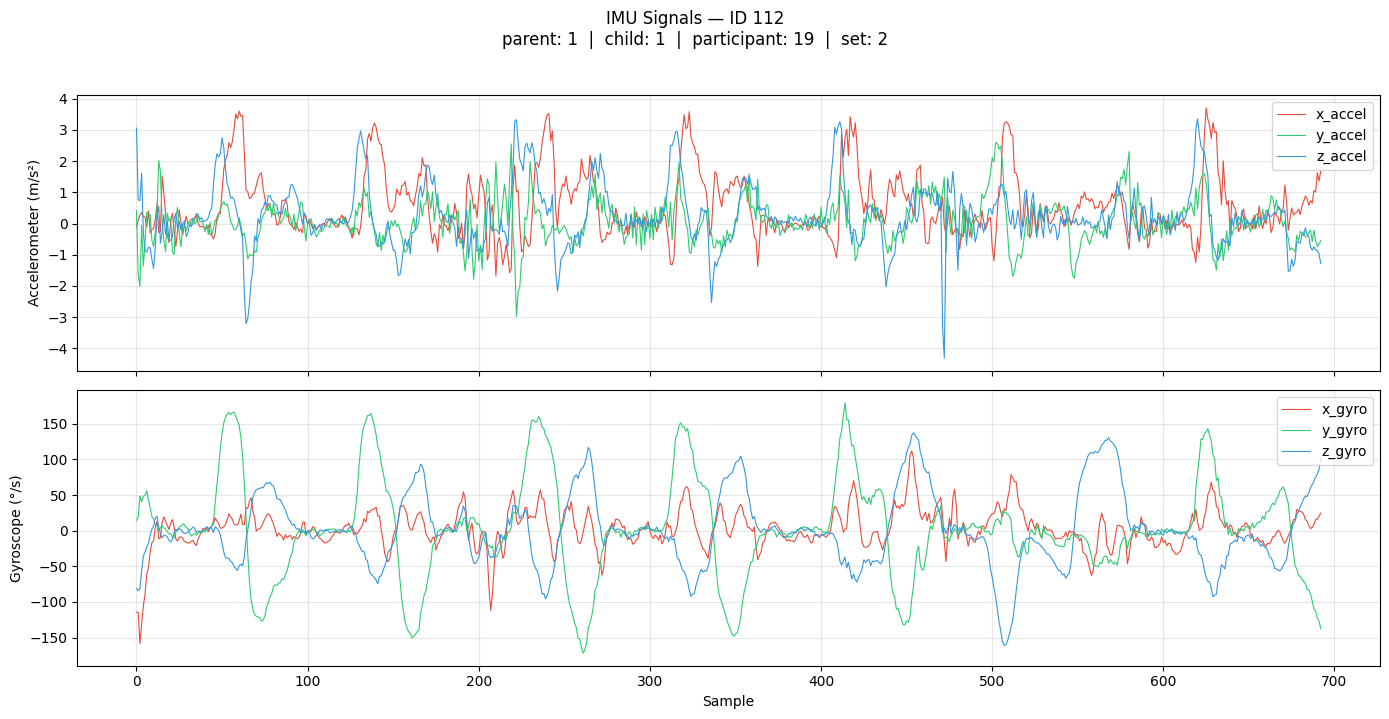

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for col, c in zip(accel_cols, COLORS):
    axes[0].plot(samples, df[col], color=c, linewidth=0.8, label=col)
axes[0].set_ylabel("Accelerometer (m/s²)")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

for col, c in zip(gyro_cols, COLORS):
    axes[1].plot(samples, df[col], color=c, linewidth=0.8, label=col)
axes[1].set_ylabel("Gyroscope (°/s)")
axes[1].set_xlabel("Sample")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

fig.suptitle(f"IMU Signals — ID {PLOT_ID}\n{meta_str}", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### 6b. Individual Channel Subplots

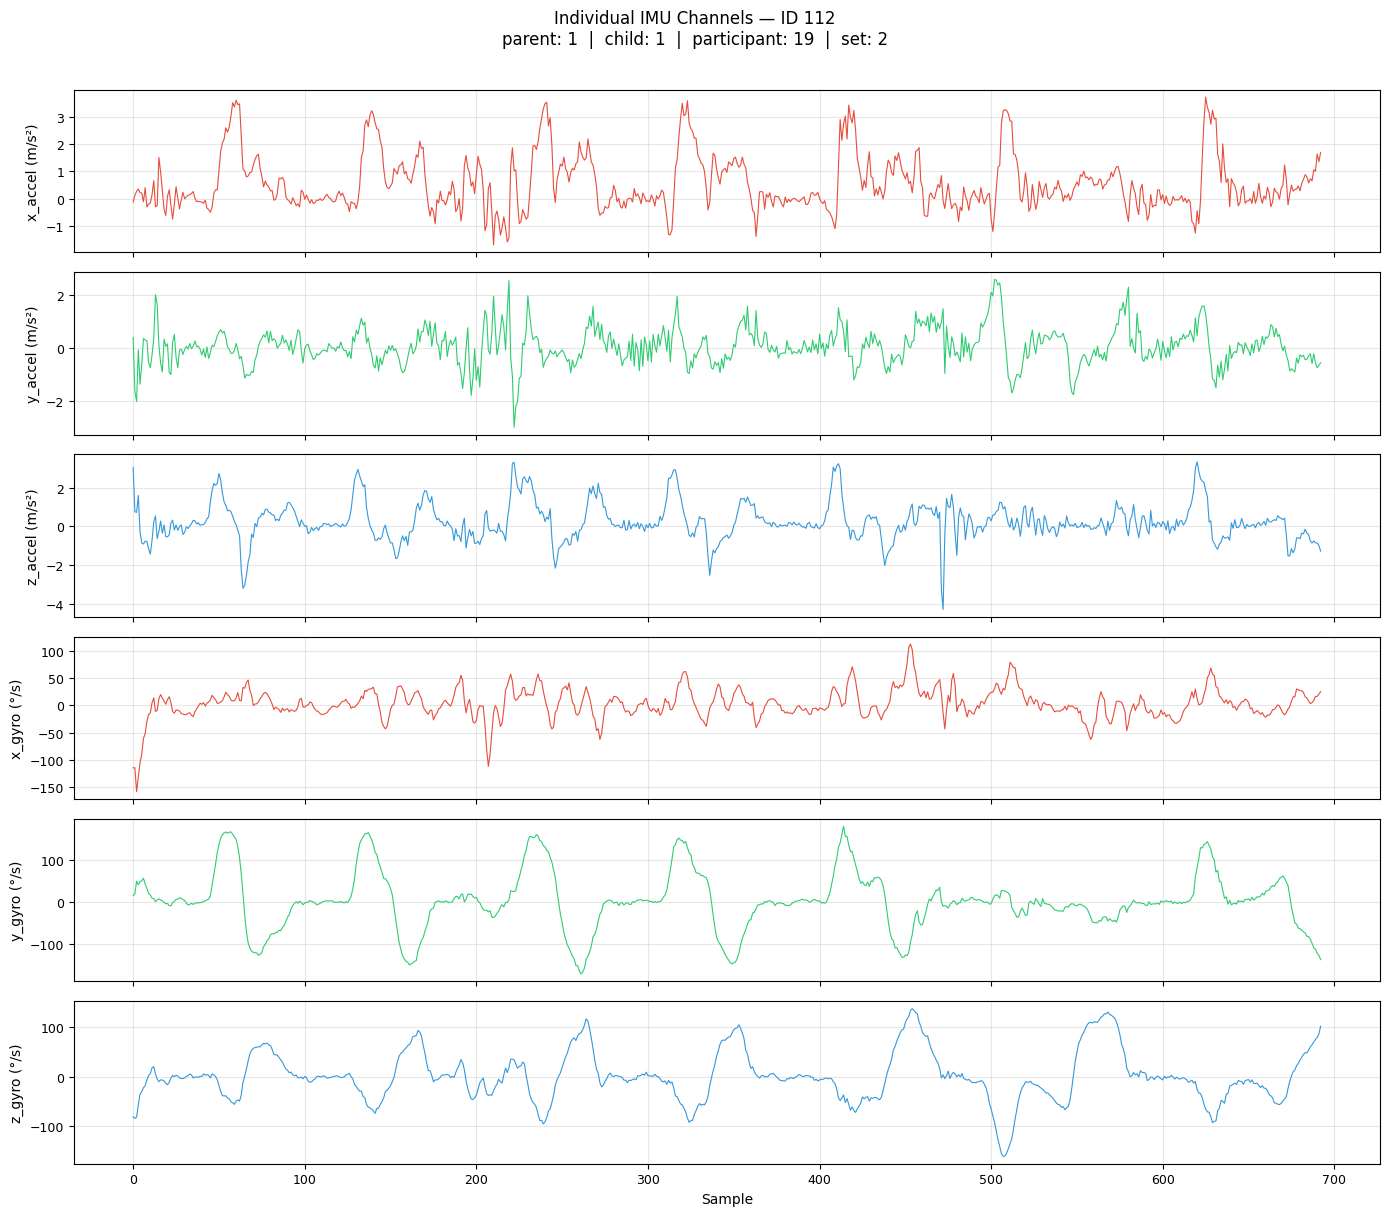

In [ ]:
fig, axes = plt.subplots(6, 1, figsize=(14, 12), sharex=True)

for i, col in enumerate(imu_cols):
    unit = "m/s²" if i < 3 else "°/s"
    axes[i].plot(samples, df[col], color=COLORS[i % 3], linewidth=0.8)
    axes[i].set_ylabel(f"{col} ({unit})", fontsize=10)
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(labelsize=9)

axes[-1].set_xlabel("Sample")
fig.suptitle(f"Individual IMU Channels — ID {PLOT_ID}\n{meta_str}", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### 6c. Signal Magnitudes

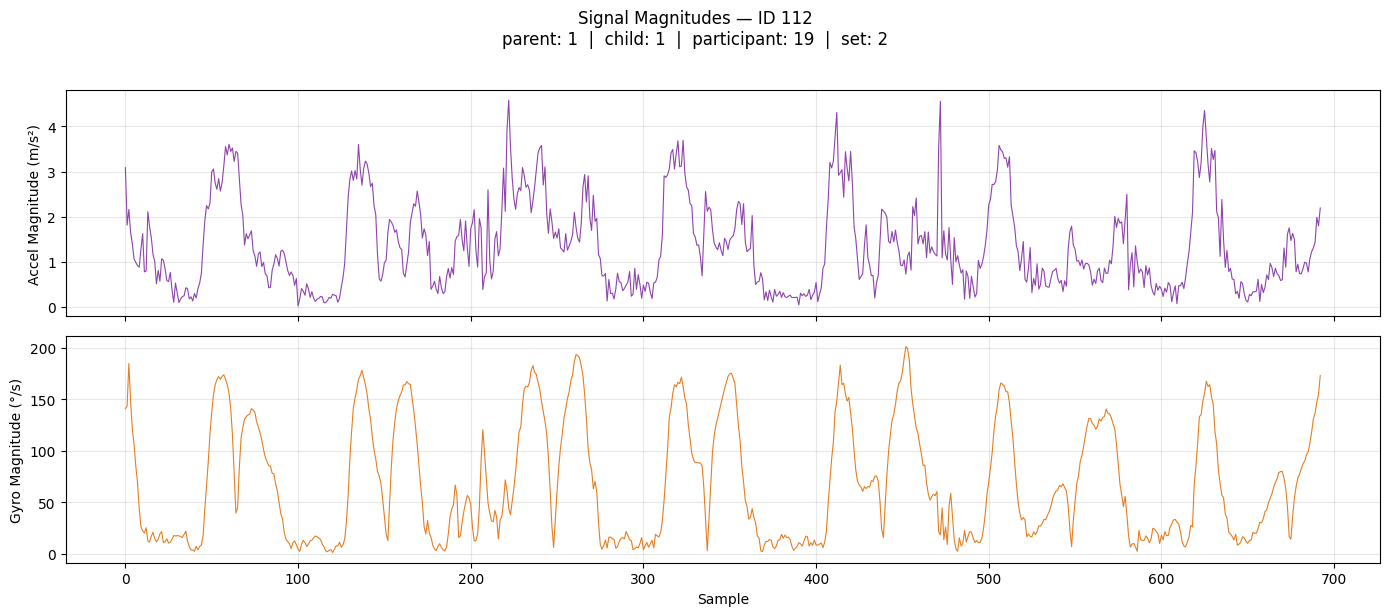

In [ ]:
accel_mag = np.sqrt(df["x_accel"]**2 + df["y_accel"]**2 + df["z_accel"]**2)
gyro_mag  = np.sqrt(df["x_gyro"]**2  + df["y_gyro"]**2  + df["z_gyro"]**2)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(samples, accel_mag, color="#8e44ad", linewidth=0.8)
axes[0].set_ylabel("Accel Magnitude (m/s²)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(samples, gyro_mag, color="#e67e22", linewidth=0.8)
axes[1].set_ylabel("Gyro Magnitude (°/s)")
axes[1].set_xlabel("Sample")
axes[1].grid(True, alpha=0.3)

fig.suptitle(f"Signal Magnitudes — ID {PLOT_ID}\n{meta_str}", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Multi-ID Comparison
Compare accelerometer signals across different exercise sets side by side.

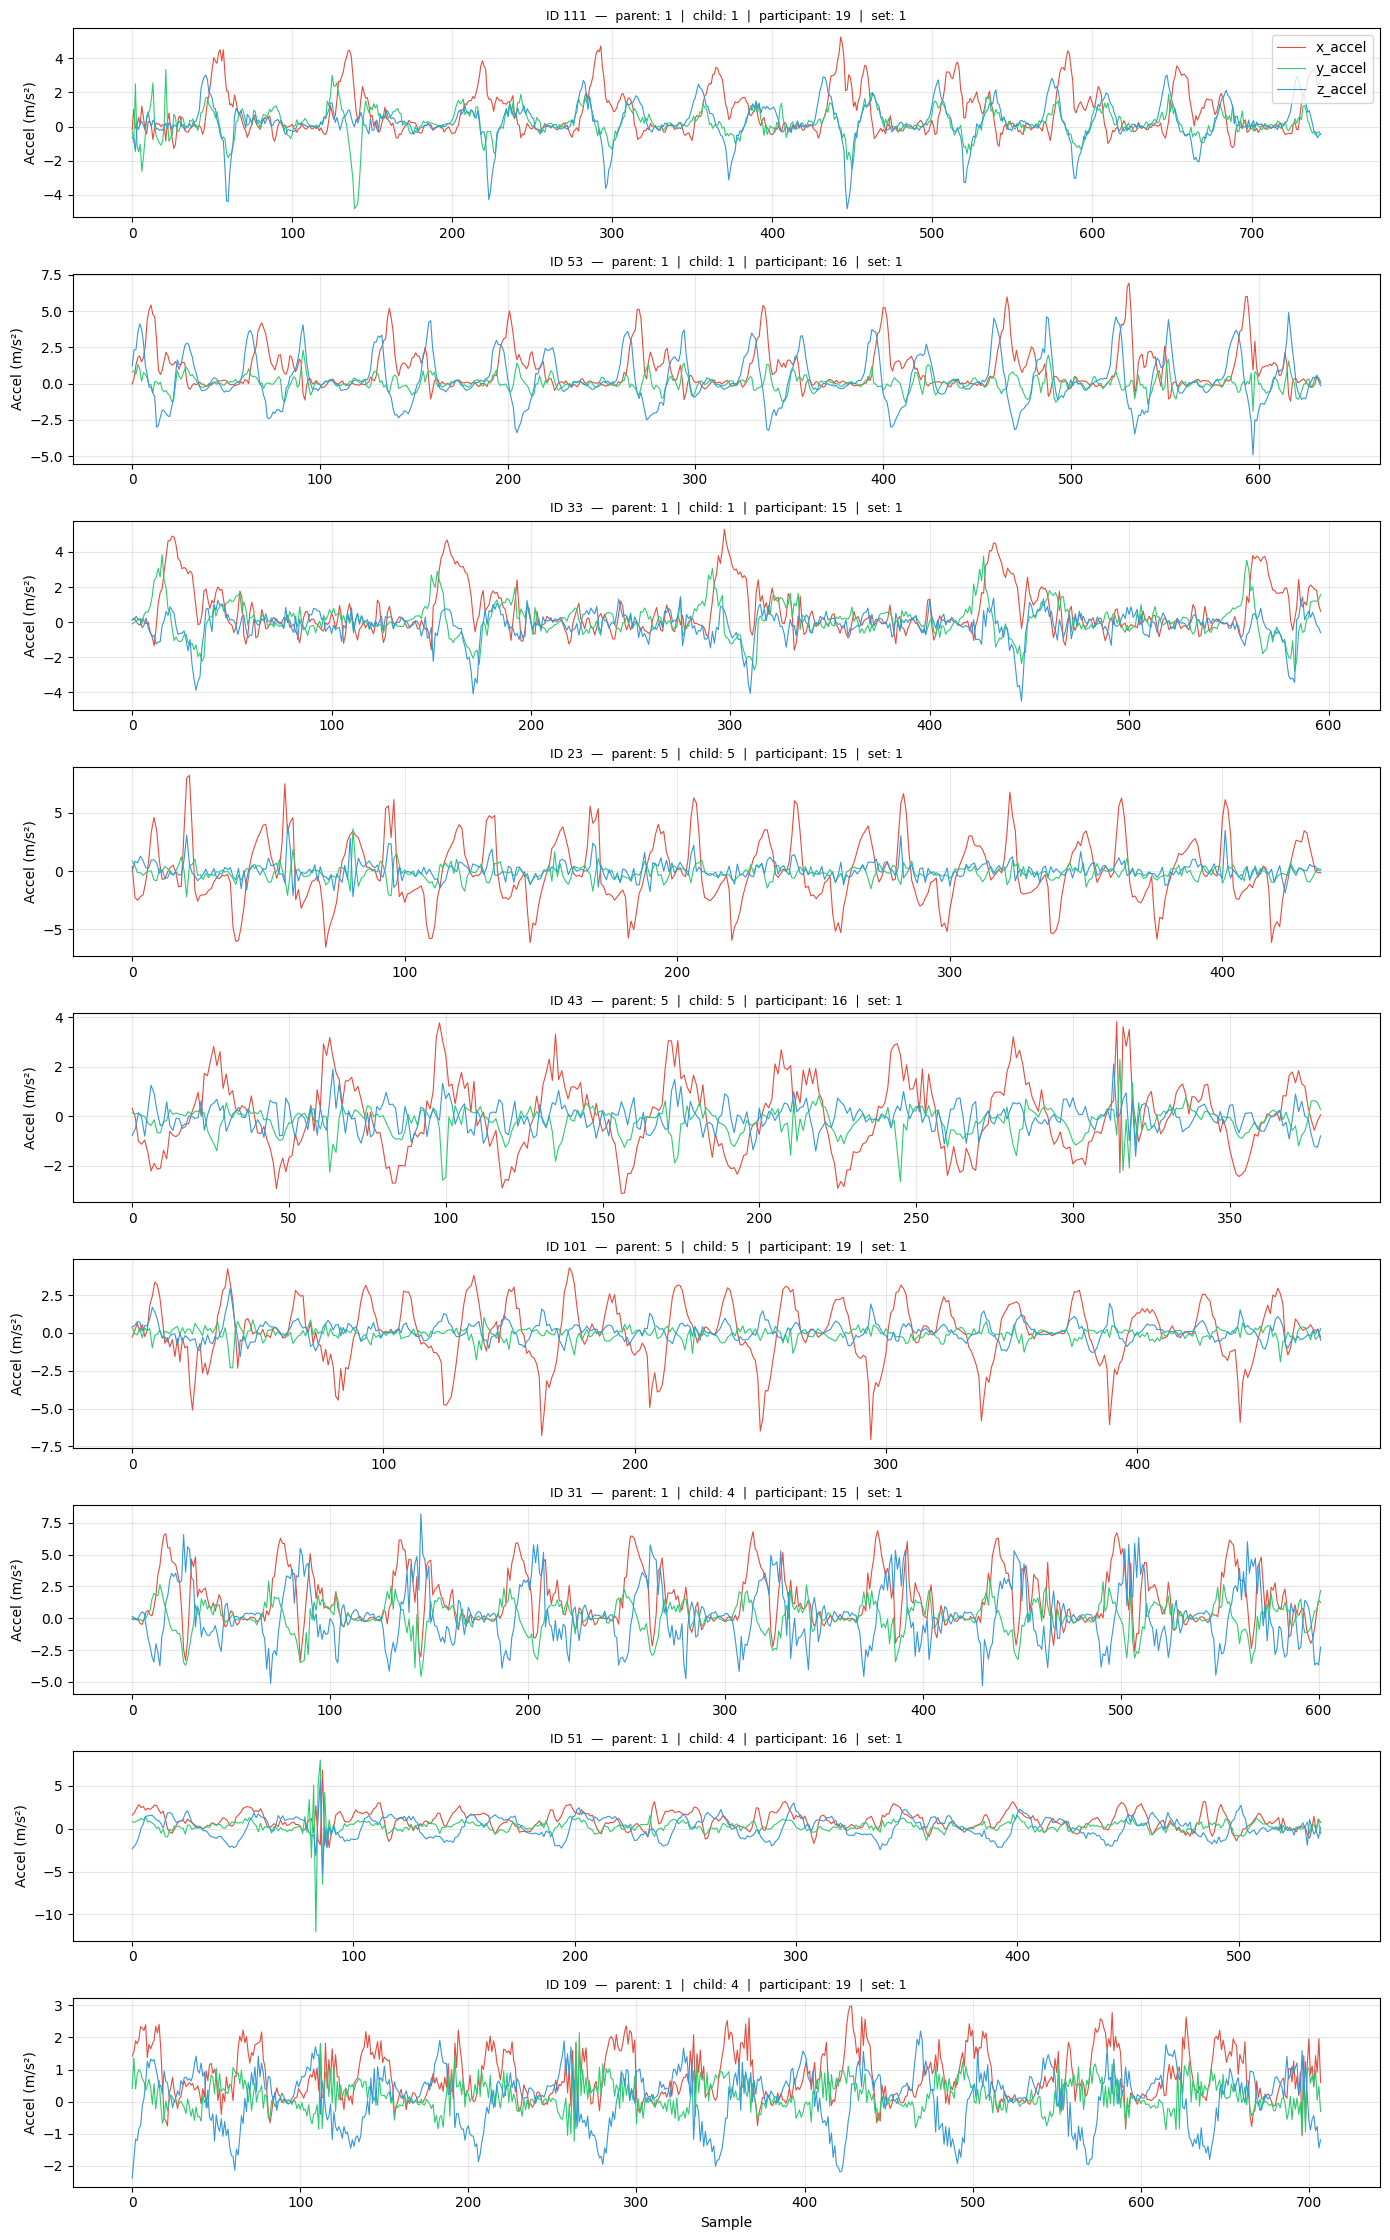

In [ ]:
compare_ids = [111, 53, 33, 23, 43, 101, 31, 51, 109]  # <-- change these to compare different sets

fig, axes = plt.subplots(len(compare_ids), 1, figsize=(14, 2.5 * len(compare_ids)), sharex=False)

for ax, rid in zip(axes, compare_ids):
    subset = df_full[df_full["ID"] == rid].reset_index(drop=True)
    local_meta = get_meta_str(df_full, rid)

    for col, c in zip(accel_cols, COLORS):
        ax.plot(subset[col], color=c, linewidth=0.8, label=col)
    ax.set_ylabel("Accel (m/s²)")
    ax.set_title(f"ID {rid}  —  {local_meta}", fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].legend(loc="upper right")
axes[-1].set_xlabel("Sample")
plt.tight_layout()
plt.show()

---
## 8. Rep Segmentation
Use peak detection on the smoothed accelerometer magnitude to find individual reps.  
The first few samples are skipped to avoid counting the unrack transient as a rep.

> **Tuning tips:** If the peak count is wrong, adjust the parameters in Section 1:
> - Too many peaks → increase `PEAK_DISTANCE` or `PEAK_PROMINENCE`
> - Too few peaks → decrease them
> - Double-bumps within a rep → increase `SMOOTH_WINDOW`

### 8a. Peak Detection

Detected 12 peaks


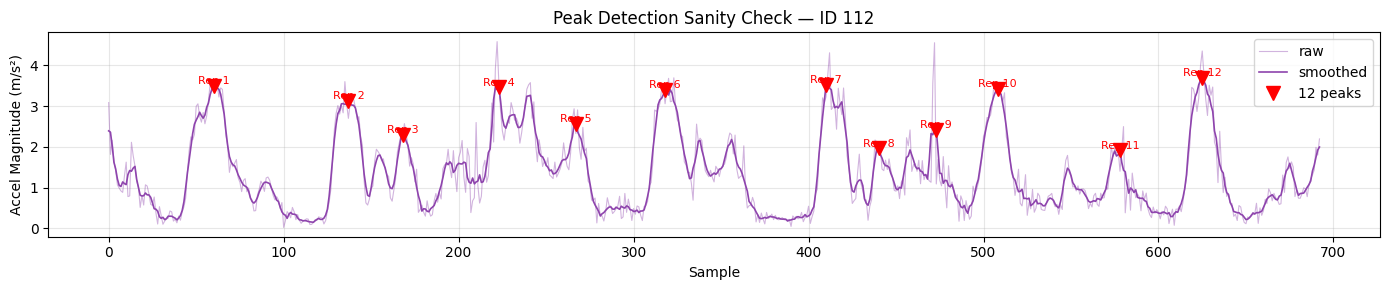

In [ ]:
accel_mag = np.sqrt(df["x_accel"]**2 + df["y_accel"]**2 + df["z_accel"]**2)
accel_smooth = uniform_filter1d(accel_mag.values, size=SMOOTH_WINDOW)

# Detect peaks, skipping initial unrack transient
peaks, properties = find_peaks(
    accel_smooth[UNRACK_SKIP:],
    distance=PEAK_DISTANCE,
    prominence=PEAK_PROMINENCE,
)
peaks = peaks + UNRACK_SKIP  # shift back to original indices

print(f"Detected {len(peaks)} peaks")

# Sanity check
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(accel_mag, color="#8e44ad", linewidth=0.8, alpha=0.4, label="raw")
ax.plot(accel_smooth, color="#8e44ad", linewidth=1.2, label="smoothed")
ax.plot(peaks, accel_smooth[peaks], "rv", markersize=10, label=f"{len(peaks)} peaks")
for i, p in enumerate(peaks):
    ax.annotate(f"Rep {i+1}", (p, accel_smooth[p] + 0.04),
                fontsize=8, ha="center", color="red")
ax.set_xlabel("Sample")
ax.set_ylabel("Accel Magnitude (m/s²)")
ax.set_title(f"Peak Detection Sanity Check — ID {PLOT_ID}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 8b. Segment into Reps

In [ ]:
# Cut at midpoints between consecutive peaks
boundaries = [0]
for i in range(len(peaks) - 1):
    boundaries.append((peaks[i] + peaks[i + 1]) // 2)
boundaries.append(len(df))

reps = [df.iloc[boundaries[i]:boundaries[i+1]].reset_index(drop=True)
        for i in range(len(boundaries) - 1)]

print(f"Segmented into {len(reps)} reps")
print(f"Samples per rep: {[len(r) for r in reps]}")

Segmented into 12 reps
Samples per rep: [98, 54, 43, 50, 47, 72, 61, 31, 34, 53, 58, 92]


In [ ]:
NORM_POINTS = 100  # resample every rep to this many points

reps_normed = []
for rep in reps:
    t_norm = np.linspace(0, 1, NORM_POINTS)
    rep_normed = pd.DataFrame()
    for col in imu_cols:
        f = interp1d(np.linspace(0, 1, len(rep)), rep[col].values, kind="linear")
        rep_normed[col] = f(t_norm)
    reps_normed.append(rep_normed)

# Print actual rep durations
durations = [len(r) / FS for r in reps]
print(f"Rep durations (sec): {[f'{d:.2f}' for d in durations]}")
print(f"Mean: {np.mean(durations):.2f}s  |  Std: {np.std(durations):.2f}s")

Rep durations (sec): ['4.90', '2.70', '2.15', '2.50', '2.35', '3.60', '3.05', '1.55', '1.70', '2.65', '2.90', '4.60']
Mean: 2.89s  |  Std: 0.99s


---
## 9. Per-Rep Visualization
### 9a. Rep Overlay (magnitude, time-normalized)
All reps overlaid on the same axes

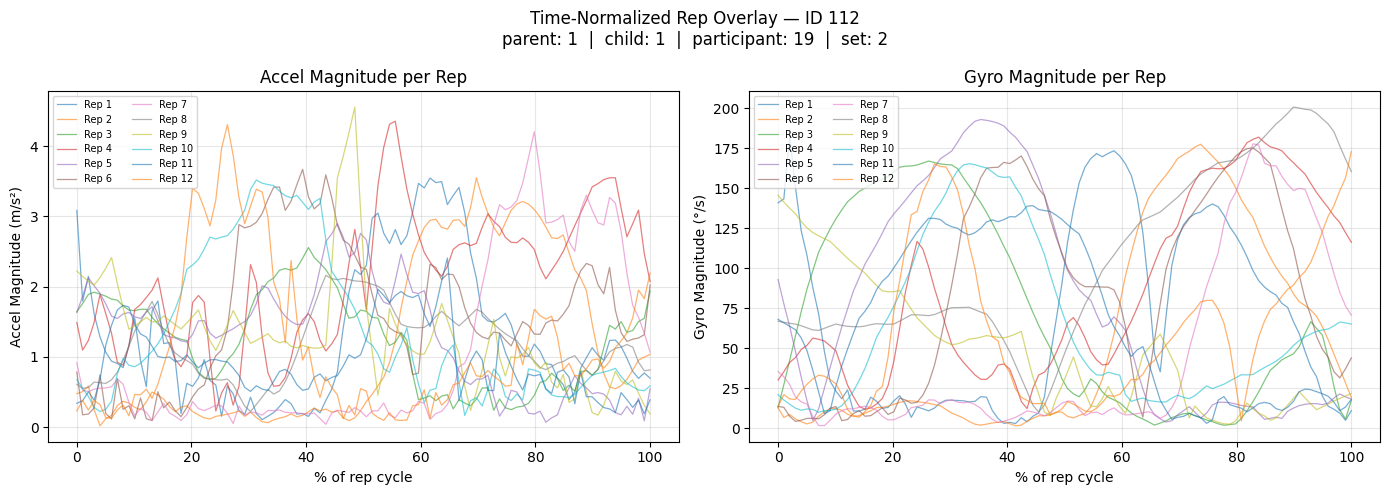

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, rep in enumerate(reps_normed):
    mag = np.sqrt(rep["x_accel"]**2 + rep["y_accel"]**2 + rep["z_accel"]**2)
    axes[0].plot(np.linspace(0, 100, NORM_POINTS), mag.values,
                 alpha=0.6, linewidth=0.9, label=f"Rep {i+1}")

for i, rep in enumerate(reps_normed):
    mag = np.sqrt(rep["x_gyro"]**2 + rep["y_gyro"]**2 + rep["z_gyro"]**2)
    axes[1].plot(np.linspace(0, 100, NORM_POINTS), mag.values,
                 alpha=0.6, linewidth=0.9, label=f"Rep {i+1}")

axes[0].set_title("Accel Magnitude per Rep")
axes[0].set_ylabel("Accel Magnitude (m/s²)")
axes[1].set_title("Gyro Magnitude per Rep")
axes[1].set_ylabel("Gyro Magnitude (°/s)")
for ax in axes:
    ax.set_xlabel("% of rep cycle")
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)
plt.suptitle(f"Time-Normalized Rep Overlay — ID {PLOT_ID}\n{meta_str}", fontsize=12)
plt.tight_layout()
plt.show()

### 9b. Grid View (dual-axis: accel + gyro per rep)
Each rep in its own subplot. Solid lines on the left y-axis = accelerometer (m/s²).  
Dashed lines on the right y-axis = gyroscope (°/s).

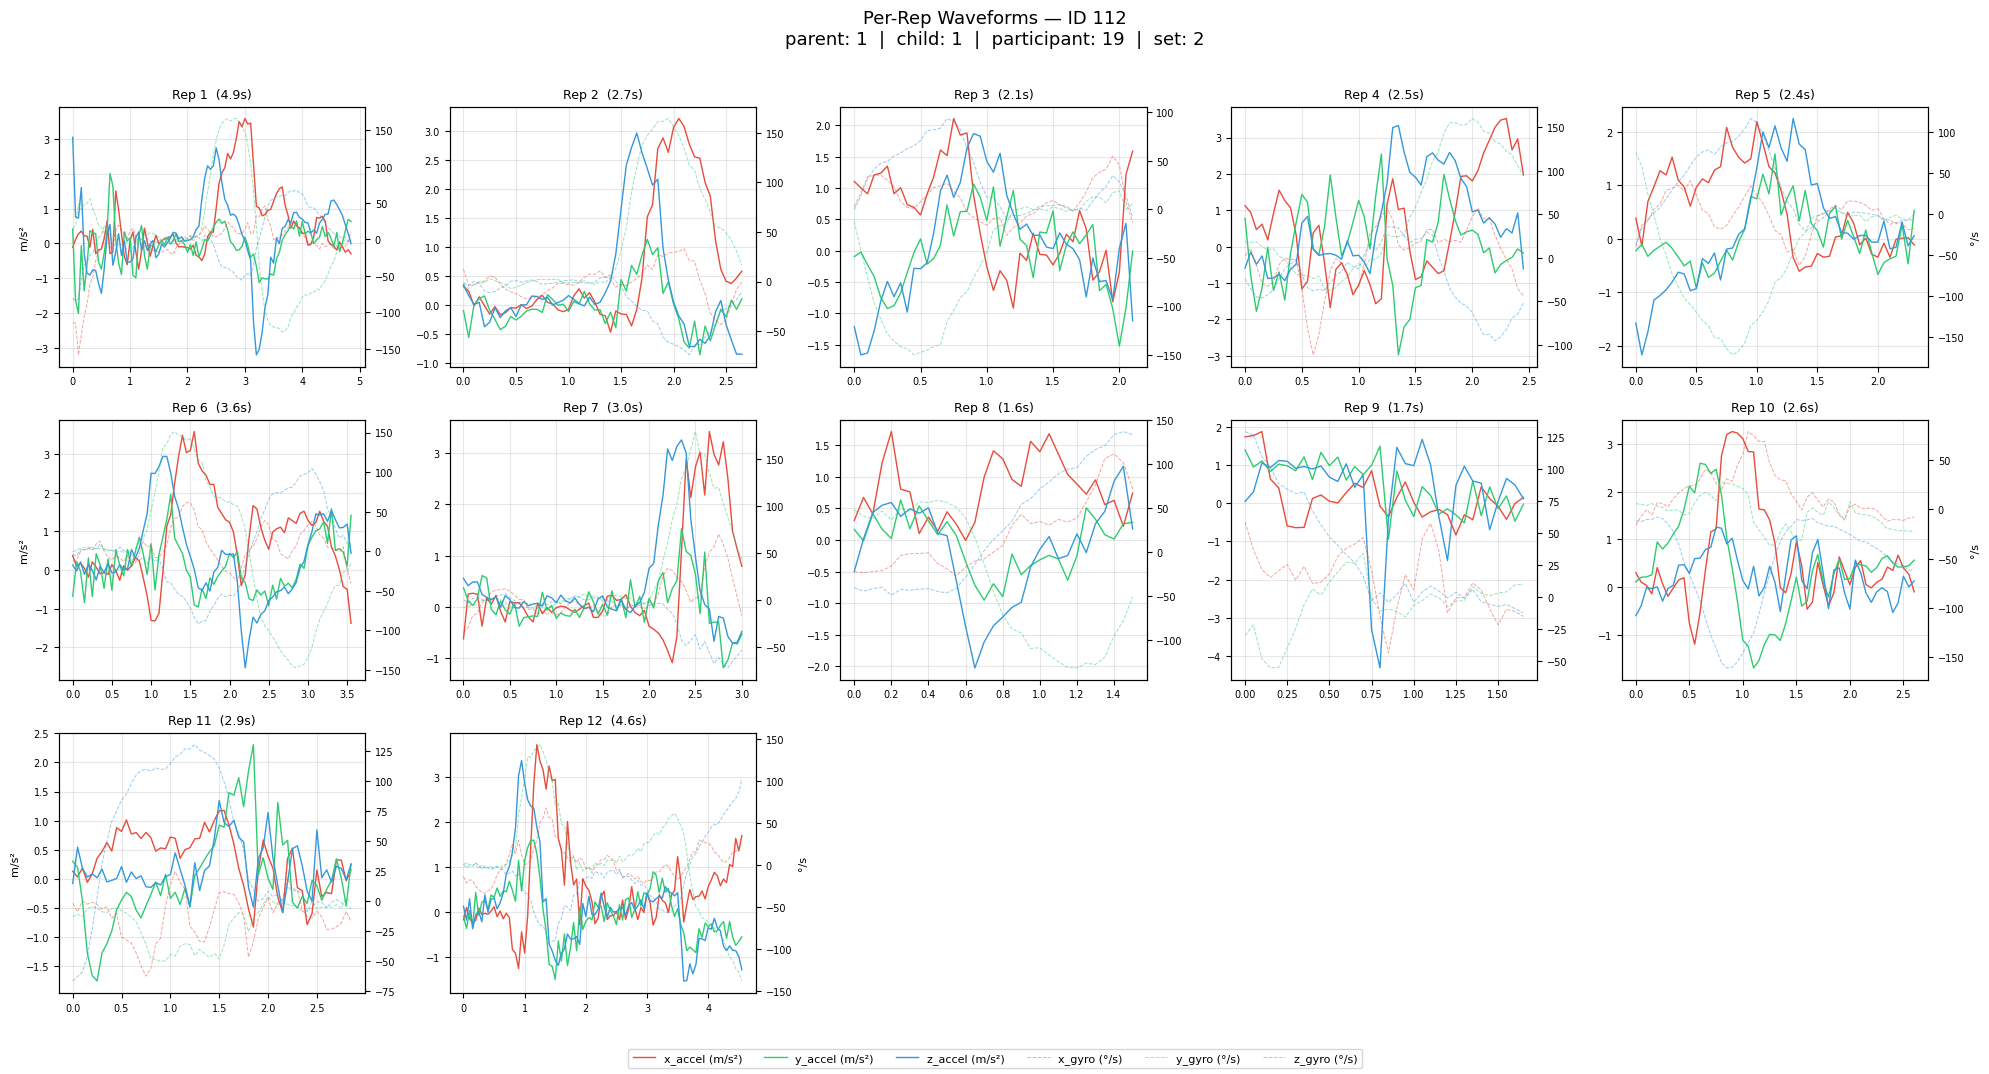

In [ ]:
n_reps = len(reps)
ncols = 5
nrows = int(np.ceil(n_reps / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 3.5 * nrows), sharex=False)
axes_flat = axes.flatten() if n_reps > ncols else (axes if isinstance(axes, np.ndarray) else [axes])

for i, rep in enumerate(reps):
    ax_accel = axes_flat[i]
    ax_gyro = ax_accel.twinx()
    s = np.arange(len(rep)) / FS

    # Accelerometer on left y-axis (solid lines)
    for col, c in zip(accel_cols, COLORS):
        ax_accel.plot(s, rep[col], color=c, linewidth=1.0)

    # Gyroscope on right y-axis (dashed lines)
    for col, c in zip(gyro_cols, COLORS):
        ax_gyro.plot(s, rep[col], color=c, linewidth=0.7, linestyle="--", alpha=0.5)

    ax_accel.set_title(f"Rep {i+1}  ({len(rep)/FS:.1f}s)", fontsize=9)
    ax_accel.grid(True, alpha=0.3)
    ax_accel.tick_params(labelsize=7)
    ax_gyro.tick_params(labelsize=7)

    # Only label outer axes to reduce clutter
    if i % ncols == 0:
        ax_accel.set_ylabel("m/s²", fontsize=8)
    if i % ncols == ncols - 1 or i == n_reps - 1:
        ax_gyro.set_ylabel("°/s", fontsize=8)

for j in range(n_reps, len(axes_flat)):
    axes_flat[j].set_visible(False)

legend_elements = (
    [Line2D([0], [0], color=c, lw=1.0, label=f"{col} (m/s²)") for col, c in zip(accel_cols, COLORS)]
  + [Line2D([0], [0], color=c, lw=0.7, ls="--", alpha=0.5, label=f"{col} (°/s)") for col, c in zip(gyro_cols, COLORS)]
)
fig.legend(handles=legend_elements, loc="lower center", ncol=6, fontsize=8)
fig.suptitle(f"Per-Rep Waveforms — ID {PLOT_ID}\n{meta_str}", fontsize=13, y=1.01)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

---
## 10. Per-Rep Grid for All IDs
Loop through every unique ID in the dataset. For each ID:
1. Compute adaptive peak detection parameters from the signal itself
2. Segment into reps
3. Produce the dual-axis per-rep grid plot

IDs where the detected rep count falls outside 7–13 are flagged for manual review.

> **Note:** The adaptive parameters are approximate. Every ID is expected to contain 10 reps.
> Flagged IDs may need hand-tuned parameters (see §1 for reference).

In [ ]:
def segment_and_plot_id(df_full, id_val, fs=20.0, smooth_window=5, unrack_skip=10,
                        expected_reps=10, flag_range=(7, 13)):
    """
    Segment one ID into reps using adaptive peak detection, then plot
    a dual-axis per-rep grid (accel on left y-axis, gyro on right).

    Returns the number of detected reps, or -1 if segmentation failed.
    """
    df_id = df_full[df_full["ID"] == id_val].reset_index(drop=True)
    if len(df_id) < 20:
        print(f"  ID {id_val}: only {len(df_id)} samples — skipping")
        return -1

    meta = get_meta_str(df_full, id_val)

    # Compute accelerometer magnitude and smooth it
    accel_mag = np.sqrt(df_id["x_accel"]**2 + df_id["y_accel"]**2 + df_id["z_accel"]**2)
    accel_smooth = uniform_filter1d(accel_mag.values, size=smooth_window)

    # --- Adaptive parameters ---
    # distance: total samples / 12 gives headroom for slightly more than 10 reps
    adapt_distance = max(5, len(df_id) // 12)

    # prominence: 15% of the smoothed signal's range
    sig = accel_smooth[unrack_skip:]
    adapt_prominence = 0.15 * (sig.max() - sig.min())

    # Detect peaks (skip unrack transient)
    try:
        peaks, _ = find_peaks(
            accel_smooth[unrack_skip:],
            distance=adapt_distance,
            prominence=adapt_prominence,
        )
        peaks = peaks + unrack_skip
    except Exception as e:
        print(f"  ID {id_val}: peak detection failed — {e}")
        return -1

    n_peaks = len(peaks)

    # Flag if outside expected range
    flag = ""
    if n_peaks < flag_range[0] or n_peaks > flag_range[1]:
        flag = f"  ⚠️  FLAGGED (expected ~{expected_reps}, got {n_peaks})"

    # Segment into reps
    boundaries = [0]
    for i in range(len(peaks) - 1):
        boundaries.append((peaks[i] + peaks[i + 1]) // 2)
    boundaries.append(len(df_id))

    reps = [df_id.iloc[boundaries[i]:boundaries[i+1]].reset_index(drop=True)
            for i in range(len(boundaries) - 1)]

    print(f"  ID {id_val}: {n_peaks} reps detected  (dist={adapt_distance}, prom={adapt_prominence:.2f}){flag}")

    # --- Plot: dual-axis grid ---
    ncols = 5
    nrows = int(np.ceil(n_peaks / ncols))
    if nrows == 0:
        return n_peaks

    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 3.5 * nrows), sharex=False)
    if nrows == 1 and ncols == 1:
        axes_flat = [axes]
    elif nrows == 1 or ncols == 1:
        axes_flat = axes if isinstance(axes, np.ndarray) else [axes]
    else:
        axes_flat = axes.flatten()

    for i, rep in enumerate(reps):
        ax_accel = axes_flat[i]
        ax_gyro = ax_accel.twinx()
        s = np.arange(len(rep)) / fs

        for col, c in zip(accel_cols, COLORS):
            ax_accel.plot(s, rep[col], color=c, linewidth=1.0)
        for col, c in zip(gyro_cols, COLORS):
            ax_gyro.plot(s, rep[col], color=c, linewidth=0.7, linestyle="--", alpha=0.5)

        ax_accel.set_title(f"Rep {i+1}  ({len(rep)/fs:.1f}s)", fontsize=9)
        ax_accel.grid(True, alpha=0.3)
        ax_accel.tick_params(labelsize=7)
        ax_gyro.tick_params(labelsize=7)

        if i % ncols == 0:
            ax_accel.set_ylabel("m/s²", fontsize=8)
        if i % ncols == ncols - 1 or i == n_peaks - 1:
            ax_gyro.set_ylabel("°/s", fontsize=8)

    for j in range(n_peaks, len(axes_flat)):
        axes_flat[j].set_visible(False)

    legend_elements = (
        [Line2D([0], [0], color=c, lw=1.0, label=f"{col} (m/s²)") for col, c in zip(accel_cols, COLORS)]
      + [Line2D([0], [0], color=c, lw=0.7, ls="--", alpha=0.5, label=f"{col} (°/s)") for col, c in zip(gyro_cols, COLORS)]
    )
    fig.legend(handles=legend_elements, loc="lower center", ncol=6, fontsize=8)
    fig.suptitle(f"Per-Rep Waveforms — ID {id_val}\n{meta}", fontsize=13, y=1.01)
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.show()

    return n_peaks

In [ ]:
# --- Run for every unique ID ---
all_ids = sorted(df_full["ID"].unique())
print(f"Processing {len(all_ids)} unique IDs...\n")

results = {}
for id_val in all_ids:
    n = segment_and_plot_id(df_full, id_val)
    results[id_val] = n

# Summary
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
flagged = {k: v for k, v in results.items() if v < 7 or v > 13}
print(f"Total IDs processed: {len(results)}")
print(f"IDs with 10 reps:    {sum(1 for v in results.values() if v == 10)}")
print(f"IDs flagged:         {len(flagged)}")
if flagged:
    print(f"Flagged IDs:         {flagged}")

Output hidden; open in https://colab.research.google.com to view.